In [ ]:
import pandas as pd
import numpy as np

In [ ]:
merged = pd.read_csv('covid_with_ratios.csv', parse_dates=['Date'])
merged = merged.sort_values(['State','Date'])

In [ ]:
# 'Confirmed' is CUMULATIVE per state, not daily new cases. We need daily new cases, so diff() within each state
merged['New_Cases'] = merged.groupby('State')['Confirmed'].diff()

# Sum New_Cases across all 36 states, for each date, to get one national number per day
national_daily = merged.groupby('Date')['New_Cases'].sum().reset_index()
national_daily = national_daily.set_index('Date')

In [ ]:
# Quick Sanity check - New_cases should never be negative
n_negative = (national_daily['New_Cases'] < 0).sum()
print(f"Days with negative national new cases: {n_negative} out of {len(national_daily)}")
print(national_daily.describe())

Days with negative national new cases: 0 out of 560
           New_Cases
count     560.000000
mean    57207.958929
std     83173.030624
min         0.000000
25%      9600.750000
50%     35420.500000
75%     62313.500000
max    414188.000000


### Time-series decomposition

Running the time-series decomposition

Gaps introduced: 0


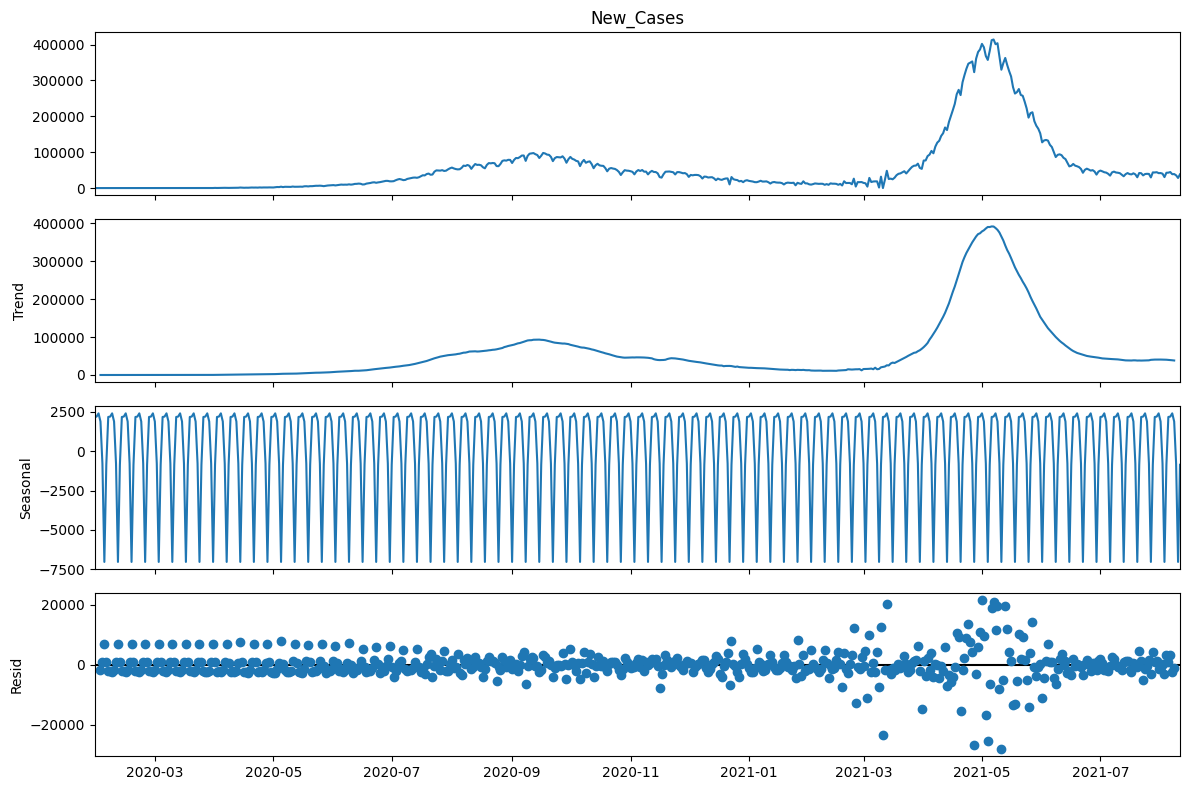

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# force a strict daily index
national_daily = national_daily.asfreq('D')
print(f"Gaps introduced: {national_daily['New_Cases'].isna().sum()}")

# interpolate the rows with NaN
national_daily['New_Cases'] = national_daily['New_Cases'].interpolate()

# take period = 7 so that it gives a weekly seasonality
result = seasonal_decompose(national_daily['New_Cases'], model='additive', period=7)

# Plotting
fig = result.plot()
fig.set_size_inches(12,8)
plt.tight_layout()

# Save figure
plt.savefig('trend_decomposition.png',dpi=100)

#### Additive vs. multiplicative decomposition — investigated, additive kept

Tested whether `model='multiplicative'` would fit better than additive

Multiplicative decomposition failed outright with a `ValueError`: it can't handle
zero values, since seasonality is expressed as a ratio, not an offset.

Kept the additive model, since forcing multiplicative would require dropping or
patching these real zero-values, which changes what's being measured. Additive
is the more honest choice here given the data as-is, even if not the theoretically
tightest fit for the growing seasonal amplitude.

In [ ]:
seasonal_by_dow = result.seasonal.groupby(result.seasonal.index.dayofweek).mean()
seasonal_by_dow.index = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
print(seasonal_by_dow)

Mon    -781.429240
Tue   -7028.537739
Wed    -857.666130
Thu    2175.406203
Fri    2199.187397
Sat    2405.476728
Sun    1887.562781
Name: seasonal, dtype: float64


On looking at the values above, Tuesday shows the sharpest drop (-7028 below the trend), while Thursday through Sunday all run above trend.

### Regression

I want to use the available data to answer these questions -


1.   is vaccination really slowing the disease growth rate?
2.   Is the number of confirmed cases related to number of cases cured?



In [ ]:
import statsmodels.api as sm

merged_1 = pd.read_csv('covid_with_ratios.csv', parse_dates=['Date'])
merged_1 = merged_1.sort_values(['State','Date'])



#### Regression 1: Vaccination rate vs Growth Rate

In [ ]:
vax_national = merged.groupby('Date').agg(
    Total_Vaccinated=('Total Individuals Vaccinated', 'sum'),
    Has_Vax_Data=('Total Individuals Vaccinated', lambda x: x.notna().any()),
    Growth_Rate=('Growth_Rate', 'mean')
).reset_index()

INDIA_POPULATION = 1_400_000_000 # Approximate population of India
vax_national['Vaccination_Rate'] = vax_national['Total_Vaccinated'] / INDIA_POPULATION

# Only keep rows where vaccination reporting had genuinely started
vax_reg = vax_national[vax_national['Has_Vax_Data']].copy()
vax_reg = vax_reg.dropna(subset=['Vaccination_Rate', 'Growth_Rate'])
vax_reg = vax_reg[np.isfinite(vax_reg['Growth_Rate'])]

print(f"Date range: {vax_reg['Date'].min()} to {vax_reg['Date'].max()}, {len(vax_reg)} rows\n")

X1 = sm.add_constant(vax_reg['Vaccination_Rate'])  # adds intercept term
y1 = vax_reg['Growth_Rate']
model1 = sm.OLS(y1, X1).fit()
print(model1.summary())

Date range: 2021-01-16 00:00:00 to 2021-06-24 00:00:00, 159 rows

                            OLS Regression Results                            
Dep. Variable:            Growth_Rate   R-squared:                       0.167
Model:                            OLS   Adj. R-squared:                  0.162
Method:                 Least Squares   F-statistic:                     31.50
Date:                Thu, 13 Aug 2026   Prob (F-statistic):           8.80e-08
Time:                        05:32:54   Log-Likelihood:                 579.54
No. Observations:                 159   AIC:                            -1155.
Df Residuals:                     157   BIC:                            -1149.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------

#### Regression 2: Confirmed vs Cured

In [ ]:
national_total = merged.groupby('Date').agg(
    Confirmed=('Confirmed', 'sum'),
    Cured=('Cured', 'sum')
).reset_index().dropna()

print(f"Rows for Confirmed vs Cured: {len(national_total)}\n")

X2 = sm.add_constant(national_total['Confirmed'])
y2 = national_total['Cured']
model2 = sm.OLS(y2, X2).fit()
print(model2.summary())

Rows for Confirmed vs Cured: 560

                            OLS Regression Results                            
Dep. Variable:                  Cured   R-squared:                       0.995
Model:                            OLS   Adj. R-squared:                  0.995
Method:                 Least Squares   F-statistic:                 1.109e+05
Date:                Thu, 13 Aug 2026   Prob (F-statistic):               0.00
Time:                        05:34:13   Log-Likelihood:                -8320.1
No. Observations:                 560   AIC:                         1.664e+04
Df Residuals:                     558   BIC:                         1.665e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2.344e

Regression 1: Does vaccination rate predict growth rate?

Result:
Coefficient (Vaccination Rate) = 0.054, p<0.001, R² = 0.167

Interpretation:
For each 1 percentage-point increase in national vaccination coverage, average grwoth rate increases by ~0.05. It's a small but statistically significant *positive* relationship which is the opposite of what is intuitive.

Regression 2: Are confirmed cases and cured cases related?

Result: Coefficient (Confirmed) = 0.9497, p<0.001, R²=0.995

Interpretation: For every 1 additional confirmed case (nationally, cumulative), ~0.95 additional cured cases follow. Near perfect linear fit. This is because a large majority of confirmed cases eventually resolve to cured within the dataset's timeframe.

Limitations


*   This analysis shows association, not causation
*   We cannot meaningfully conclude that vaccination caused rise in growth rate; it would just mean that higher vaccination rate coincidentally matched the Delta wave case rises in India

